# Demand-side

Goal: initialize demand-side analysis with customer cohort retention views, then roll the visualization up to first-order month-of-year for easier seasonal comparison.

## Setup

In [ ]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

DERIVED_DATA_DIR = PROJECT_ROOT / "data" / "derived"

pd.set_option("display.max_columns", 80)
pd.set_option("display.float_format", "{:.4f}".format)

PLOT_RCPARAMS = {
    "figure.figsize": (11, 6),
    "figure.dpi": 120,
    "savefig.dpi": 150,
    "savefig.bbox": "tight",
    "axes.titlesize": 14,
    "axes.titleweight": "bold",
    "axes.labelsize": 11,
    "axes.grid": True,
    "axes.axisbelow": True,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "grid.alpha": 0.25,
    "grid.linewidth": 0.8,
    "legend.frameon": False,
    "legend.fontsize": 10,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "lines.linewidth": 2.0,
    "lines.markersize": 5,
    "patch.edgecolor": "white",
    "patch.linewidth": 0.5,
}
plt.rcParams.update(PLOT_RCPARAMS)
sns.set_theme(style="whitegrid", palette="Set2", rc=PLOT_RCPARAMS)

## Load Demand-side Tables

In [2]:
customer_fact = pd.read_csv(
    DERIVED_DATA_DIR / "customer_fact_table.csv",
    parse_dates=[
        "signup_date",
        "first_order_date",
        "second_order_date",
        "last_order_date",
        "last_return_date",
        "latest_review_date",
    ],
)

order_fact = pd.read_csv(
    DERIVED_DATA_DIR / "order_fact_table.csv",
    parse_dates=[
        "order_date",
        "order_month",
        "ship_date",
        "delivery_date",
        "first_return_date",
        "last_return_date",
        "first_review_date",
        "latest_review_date",
    ],
)

customer_cohort_activity = pd.read_csv(
    DERIVED_DATA_DIR / "customer_cohort_activity_fact.csv",
    parse_dates=[
        "first_order_cohort_month",
        "signup_cohort_month",
        "order_month",
    ],
)

signup_activation = pd.read_csv(
    DERIVED_DATA_DIR / "signup_activation_fact.csv",
    parse_dates=[
        "signup_date",
        "signup_cohort_month",
        "first_order_date",
        "second_order_date",
        "activation_month",
    ],
)

{
    "customer_fact": customer_fact.shape,
    "order_fact": order_fact.shape,
    "customer_cohort_activity": customer_cohort_activity.shape,
    "signup_activation": signup_activation.shape,
}

{'customer_fact': (121930, 46),
 'order_fact': (646945, 41),
 'customer_cohort_activity': (586976, 13),
 'signup_activation': (121930, 14)}

In [3]:
order_fact[["order_id", "order_date", "customer_id", "order_status", "device_type", "order_source"]].head()

,order_id,order_date,customer_id,order_status,device_type,order_source
0,5280,2012-07-25,1,delivered,desktop,paid_search
1,184922,2014-05-31,1,returned,mobile,referral
2,308113,2015-07-31,1,delivered,mobile,paid_search
3,483190,2017-04-23,1,delivered,mobile,paid_search
4,702081,2020-02-24,1,delivered,mobile,organic_search


# Chart 1: Funnel: Customer Order Status Flow

Compute the customer split from all customers into no-order and ordered customers, then split ordered customers into one-time and repeat buyers.

In [ ]:
funnel_customer_base = customer_fact[["customer_id", "signup_date", "orders_count"]].copy()
funnel_total_customers = int(funnel_customer_base["customer_id"].nunique())

funnel_stage = funnel_customer_base.rename(columns={"orders_count": "order_count"})
funnel_stage["order_count"] = funnel_stage["order_count"].fillna(0).astype(int)
funnel_stage["has_order"] = funnel_stage["order_count"] >= 1
funnel_stage["is_one_time_buyer"] = funnel_stage["order_count"] == 1
funnel_stage["is_repeat_buyer"] = funnel_stage["order_count"] >= 2

ordered_customers_count = int(funnel_stage["has_order"].sum())
no_order_customers_count = funnel_total_customers - ordered_customers_count
one_time_buyers_count = int(funnel_stage["is_one_time_buyer"].sum())
repeat_buyers_count = int(funnel_stage["is_repeat_buyer"].sum())

funnel_stage_counts = pd.DataFrame(
    [
        {"stage": "All Customers", "parent_stage": pd.NA, "customers": funnel_total_customers},
        {"stage": "No Order", "parent_stage": "All Customers", "customers": no_order_customers_count},
        {"stage": "Ordered Customers", "parent_stage": "All Customers", "customers": ordered_customers_count},
        {"stage": "One-time Buyers", "parent_stage": "Ordered Customers", "customers": one_time_buyers_count},
        {"stage": "Repeat Buyers", "parent_stage": "Ordered Customers", "customers": repeat_buyers_count},
    ]
)
funnel_stage_counts["share_of_parent"] = [
    1.0,
    no_order_customers_count / funnel_total_customers if funnel_total_customers > 0 else pd.NA,
    ordered_customers_count / funnel_total_customers if funnel_total_customers > 0 else pd.NA,
    one_time_buyers_count / ordered_customers_count if ordered_customers_count > 0 else pd.NA,
    repeat_buyers_count / ordered_customers_count if ordered_customers_count > 0 else pd.NA,
]
funnel_stage_counts["share_of_all_customers"] = [
    1.0,
    no_order_customers_count / funnel_total_customers if funnel_total_customers > 0 else pd.NA,
    ordered_customers_count / funnel_total_customers if funnel_total_customers > 0 else pd.NA,
    one_time_buyers_count / funnel_total_customers if funnel_total_customers > 0 else pd.NA,
    repeat_buyers_count / funnel_total_customers if funnel_total_customers > 0 else pd.NA,
]

order_join_check = order_fact[["order_id", "customer_id"]].merge(
    funnel_customer_base[["customer_id"]],
    on="customer_id",
    how="left",
    indicator=True,
)
matched_orders = int((order_join_check["_merge"] == "both").sum())
unmatched_orders = int((order_join_check["_merge"] == "left_only").sum())

funnel_checks = pd.DataFrame(
    [
        {
            "customer_order_join_coverage_pct": matched_orders / len(order_join_check) if len(order_join_check) > 0 else pd.NA,
            "orders_with_missing_customer_dim_key": unmatched_orders,
            "customers_with_missing_signup_date": int(funnel_customer_base["signup_date"].isna().sum()),
            "customers_with_missing_signup_date_pct": float(funnel_customer_base["signup_date"].isna().mean()),
            "no_order_customers_count": no_order_customers_count,
            "no_order_customers_pct": no_order_customers_count / funnel_total_customers if funnel_total_customers > 0 else pd.NA,
            "ordered_customers_count": ordered_customers_count,
            "one_time_buyers_count": one_time_buyers_count,
            "repeat_buyers_count": repeat_buyers_count,
            "buyer_split_reconciles_flag": bool(
                one_time_buyers_count + repeat_buyers_count == ordered_customers_count
            ),
        }
    ]
)

display(funnel_stage_counts)
funnel_checks

,stage,parent_stage,customers,share_of_parent,share_of_all_customers
0,All Customers,NaN,121930,1.0000,1.0000
1,No Order,All Customers,31684,0.2599,0.2599
2,Ordered Customers,All Customers,90246,0.7401,0.7401
3,One-time Buyers,Ordered Customers,22358,0.2477,0.1834
4,Repeat Buyers,Ordered Customers,67888,0.7523,0.5568


,customer_order_join_coverage_pct,orders_with_missing_customer_dim_key,customers_with_missing_signup_date,customers_with_missing_signup_date_pct,no_order_customers_count,no_order_customers_pct,ordered_customers_count,one_time_buyers_count,repeat_buyers_count,buyer_split_reconciles_flag
0,1.0000,0,0,0.0000,31684,0.2599,90246,22358,67888,True


In [13]:
import plotly.graph_objects as go

sankey_labels = [
    "All Customers",
    "Ordered Customers",
    "One-time Buyers",
    "Repeat Buyers",
    "No Order",
]
sankey_label_to_index = {label: idx for idx, label in enumerate(sankey_labels)}
sankey_node_counts = {
    "All Customers": funnel_total_customers,
    "Ordered Customers": ordered_customers_count,
    "One-time Buyers": one_time_buyers_count,
    "Repeat Buyers": repeat_buyers_count,
    "No Order": no_order_customers_count,
}
sankey_node_labels = [
    f"{label}<br>{sankey_node_counts[label]:,} ({sankey_node_counts[label] / funnel_total_customers:.1%})"
    if funnel_total_customers > 0 else label
    for label in sankey_labels
]

sankey_links = pd.DataFrame(
    [
        {"source": "All Customers", "target": "Ordered Customers", "customers": ordered_customers_count},
        {"source": "Ordered Customers", "target": "One-time Buyers", "customers": one_time_buyers_count},
        {"source": "Ordered Customers", "target": "Repeat Buyers", "customers": repeat_buyers_count},
        {"source": "All Customers", "target": "No Order", "customers": no_order_customers_count},
    ]
)
sankey_links["source_customers"] = sankey_links["source"].map(sankey_node_counts)
sankey_links["share_of_parent"] = sankey_links["customers"] / sankey_links["source_customers"]
sankey_links["share_of_all_customers"] = sankey_links["customers"] / funnel_total_customers
sankey_links["hover_count"] = sankey_links["customers"].map(lambda value: f"{value:,}")

fig = go.Figure(
    data=[
        go.Sankey(
            arrangement="snap",
            node={
                "label": sankey_node_labels,
                "pad": 18,
                "thickness": 18,
                "color": ["#2f4b7c", "#a05195", "#00876c", "#ffa600", "#d45087"],
            },
            link={
                "source": sankey_links["source"].map(sankey_label_to_index),
                "target": sankey_links["target"].map(sankey_label_to_index),
                "value": sankey_links["customers"],
                "customdata": sankey_links[["hover_count", "share_of_parent", "share_of_all_customers"]],
                "hovertemplate": "%{source.label} -> %{target.label}<br>%{customdata[0]} customers<br>%{customdata[1]:.1%} of parent<br>%{customdata[2]:.1%} of all customers<extra></extra>",
            },
        )
    ]
)
fig.update_layout(
    title_text="Customer Order Status Flow",
    height=480,
    margin={"l": 20, "r": 20, "t": 60, "b": 20},
    font={"size": 12},
)
fig.show()

## Normalized Funnel Leakage Comparison

Normalize no-order customers against all customers and one-time buyers against ordered customers, so each leakage point is compared against the population that could leak at that step.

In [15]:
leakage_comparison = pd.DataFrame(
    [
        {
            "leakage_point": "No Order",
            "leakage_definition": "Customer signed up but never placed an order",
            "leakage_customers": no_order_customers_count,
            "base_population": "All Customers",
            "base_customers": funnel_total_customers,
        },
        {
            "leakage_point": "One-time Buyers",
            "leakage_definition": "Customer placed exactly one order and did not repeat",
            "leakage_customers": one_time_buyers_count,
            "base_population": "Ordered Customers",
            "base_customers": ordered_customers_count,
        },
    ]
)

leakage_comparison["normalized_leakage_rate"] = (
    leakage_comparison["leakage_customers"] / leakage_comparison["base_customers"]
)
leakage_comparison["share_of_all_customers"] = (
    leakage_comparison["leakage_customers"] / funnel_total_customers
)
leakage_comparison["customers_per_1k_base"] = (
    leakage_comparison["normalized_leakage_rate"] * 1000
).round(1)

leakage_comparison.sort_values("normalized_leakage_rate", ascending=False)

,leakage_point,leakage_definition,leakage_customers,base_population,base_customers,normalized_leakage_rate,share_of_all_customers,customers_per_1k_base
0,No Order,Customer signed up but never placed an order,31684,All Customers,121930,0.2599,0.2599,259.9000
1,One-time Buyers,Customer placed exactly one order and did not ...,22358,Ordered Customers,90246,0.2477,0.1834,247.7000


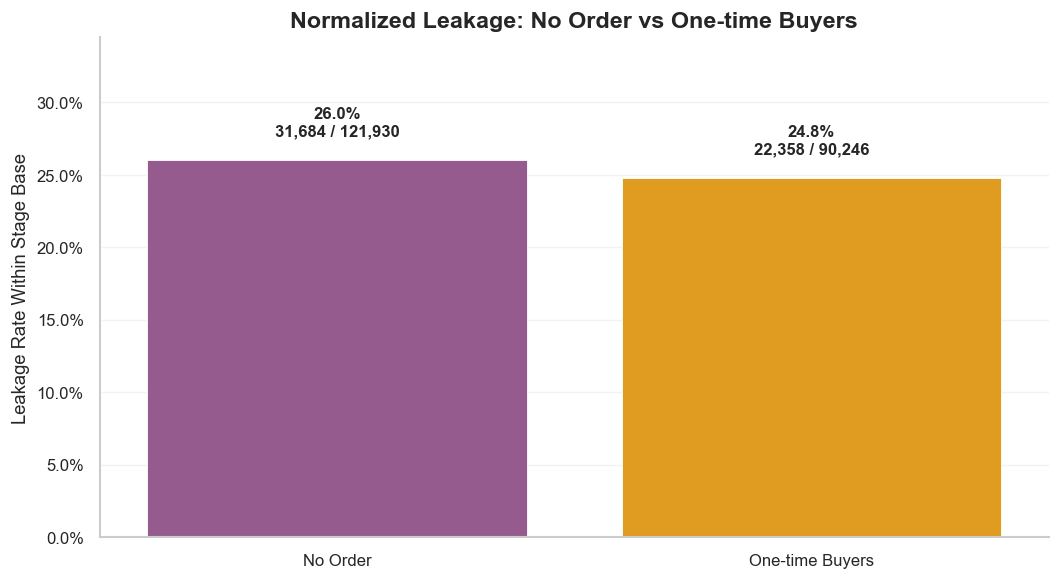

In [16]:
import matplotlib.ticker as mtick

plot_leakage = leakage_comparison.sort_values("normalized_leakage_rate", ascending=True).copy()
leakage_gap_pp = (
    plot_leakage["normalized_leakage_rate"].max()
    - plot_leakage["normalized_leakage_rate"].min()
) * 100

fig, ax = plt.subplots(figsize=(11, 5.5))
sns.barplot(
    data=plot_leakage,
    x="normalized_leakage_rate",
    y="leakage_point",
    hue="leakage_point",
    palette={"One-time Buyers": "#ffa600", "No Order": "#a05195"},
    legend=False,
    ax=ax,
)

for idx, row in plot_leakage.reset_index(drop=True).iterrows():
    ax.text(
        row["normalized_leakage_rate"] + 0.006,
        idx,
        (
            f"{row['normalized_leakage_rate']:.1%} of {row['base_population']}"
            f"\n{int(row['leakage_customers']):,} / {int(row['base_customers']):,} customers"
            f"\n{row['share_of_all_customers']:.1%} of all customers"
        ),
        ha="left",
        va="center",
        fontsize=10,
        color="#222222",
    )

ax.set_title("Normalized Demand Leakage by Funnel Stage")
ax.text(
    0,
    1.08,
    f"Rates use each stage's eligible base. Normalized gap: {leakage_gap_pp:.1f} percentage points.",
    transform=ax.transAxes,
    ha="left",
    va="bottom",
    fontsize=10,
    color="#444444",
)
ax.set_xlabel("Leakage Rate Within Stage Base")
ax.set_ylabel("")
ax.xaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax.set_xlim(0, min(1.0, plot_leakage["normalized_leakage_rate"].max() + 0.20))
ax.margins(x=0, y=0.12)
ax.spines["left"].set_position(("data", 0))
ax.grid(axis="x", alpha=0.25)
ax.set_axisbelow(True)
plt.tight_layout()

### Business Insight

> Funnel là điểm mở đầu của câu chuyện demand: trước khi nói đến giữ chân, doanh nghiệp phải giải quyết việc có đủ khách đi qua bước mua đầu tiên hay không.

### Hiện trạng dữ liệu
- Tổng tệp có **121,930** khách; trong đó **31,684 khách không phát sinh đơn** (**26.0%**).
- Trong **90,246** khách đã từng mua, có **22,358 khách chỉ mua 1 lần** (**24.8%** nhóm đã mua).
- Hai điểm rò rỉ có quy mô gần tương đương nhau, nên vấn đề demand không nằm ở một bước đơn lẻ mà nằm ở cả khả năng kích hoạt lẫn khả năng kéo khách quay lại.

### Diễn giải vấn đề
- Đây là tầng gốc của toàn bộ câu chuyện demand: nếu khách không vào được đơn đầu, mọi nỗ lực retention sau đó đều không có base đủ lớn.
- Khi đã vào được đơn đầu nhưng dừng ở one-time, doanh nghiệp đang mất luôn phần demand có chất lượng cao hơn vì khách đã chứng minh được nhu cầu mua.
- Nói cách khác, Chart 1 cho thấy hai cửa rò rỉ: cửa trước khi mua và cửa ngay sau khi mua. Vì vậy, sau khi xác định điểm nghẽn ở bước sau đơn đầu, phân tích cần đi tiếp vào câu hỏi cốt lõi: nhóm khách đã mua có quay lại đủ đều theo thời gian hay không.

### Tác động đến doanh nghiệp
- CAC bị đội lên vì một phần lớn khách đăng ký không chuyển thành doanh thu.
- Doanh thu tương lai bị nén vì nhiều khách dừng ở one-time, làm LTV trung bình khó cải thiện.
- Các chương trình retention dài hạn sẽ kém hiệu quả nếu base khách qua được đơn đầu không đủ lớn.

### Đề xuất ngắn gọn
- Ưu tiên 90 ngày tới: tăng tỷ lệ signup -> first order, đồng thời thiết kế gói giữ chân sau đơn đầu (30-90 ngày) cho nhóm rủi ro one-time cao.

# Chart 2: Cohort Anchor Check

Retention is anchored on **first observed order month** rather than `signup_date`. In this dataset, many customers place an order before their recorded signup date, so signup-based retention would not represent ordering behavior cleanly.

In [18]:
cohort_anchor_check = customer_fact[["customer_id", "signup_date", "first_order_date"]].copy()
signup_after_first_order = cohort_anchor_check["first_order_date"] < cohort_anchor_check["signup_date"]

pd.DataFrame(
    [
        {
            "customers_with_orders": len(cohort_anchor_check),
            "missing_signup_date": int(cohort_anchor_check["signup_date"].isna().sum()),
            "signup_after_first_order": int(signup_after_first_order.sum()),
            "pct_signup_after_first_order": float(signup_after_first_order.mean()),
        }
    ]
)

,customers_with_orders,missing_signup_date,signup_after_first_order,pct_signup_after_first_order
0,121930,0,80623,0.6612


## Build Cohort Retention Table

In [19]:
cohort_sizes = (
    customer_fact.dropna(subset=["first_order_date"])
    .assign(cohort_month=lambda df: df["first_order_date"].dt.to_period("M").dt.to_timestamp())
    .groupby("cohort_month", as_index=False)
    .agg(cohort_size=("customer_id", "nunique"))
)

retention_counts = (
    customer_cohort_activity.rename(columns={"first_order_cohort_month": "cohort_month"})
    .groupby(["cohort_month", "cohort_index"], as_index=False)
    .agg(active_customers=("customer_id", "nunique"))
    .merge(cohort_sizes, on="cohort_month", how="left")
)
retention_counts["retention_rate"] = retention_counts["active_customers"] / retention_counts["cohort_size"]
retention_counts["cohort_start_month"] = retention_counts["cohort_month"].dt.month_name().str.slice(stop=3)

retention_counts.head(12)

,cohort_month,cohort_index,active_customers,cohort_size,retention_rate,cohort_start_month
0,2012-07-01,0,4883,4883,1.0000,Jul
1,2012-07-01,1,673,4883,0.1378,Jul
2,2012-07-01,2,589,4883,0.1206,Jul
3,2012-07-01,3,440,4883,0.0901,Jul
4,2012-07-01,4,443,4883,0.0907,Jul
5,2012-07-01,5,632,4883,0.1294,Jul
6,2012-07-01,6,419,4883,0.0858,Jul
7,2012-07-01,7,487,4883,0.0997,Jul
8,2012-07-01,8,692,4883,0.1417,Jul
9,2012-07-01,9,879,4883,0.1800,Jul


In [20]:
retention_heatmap = retention_counts.pivot(
    index="cohort_month",
    columns="cohort_index",
    values="retention_rate",
)
retention_heatmap.iloc[:8, :8]

cohort_index,0,1,2,3,4,5,6,7
cohort_month,,,,,,,,
2012-07-01,1.0000,0.1378,0.1206,0.0901,0.0907,0.1294,0.0858,0.0997
2012-08-01,1.0000,0.1134,0.0918,0.0917,0.1245,0.0751,0.0897,0.1243
2012-09-01,1.0000,0.0947,0.0856,0.1190,0.0804,0.0845,0.1154,0.1566
2012-10-01,1.0000,0.0822,0.1198,0.0734,0.0959,0.1172,0.1529,0.1419
2012-11-01,1.0000,0.1226,0.0661,0.0884,0.1090,0.1248,0.1322,0.1327
2012-12-01,1.0000,0.0592,0.0732,0.0999,0.1250,0.1293,0.1241,0.1108
2013-01-01,1.0000,0.0766,0.0939,0.1367,0.1171,0.1254,0.1129,0.1111
2013-02-01,1.0000,0.0982,0.1298,0.1204,0.1199,0.1043,0.0940,0.0855


## Month-of-year Cohort Retention Heatmap

The detailed cohort table above is retained for inspection. For visualization, cohorts are grouped by the **month of first order** across years so the seasonal pattern is easier to compare.

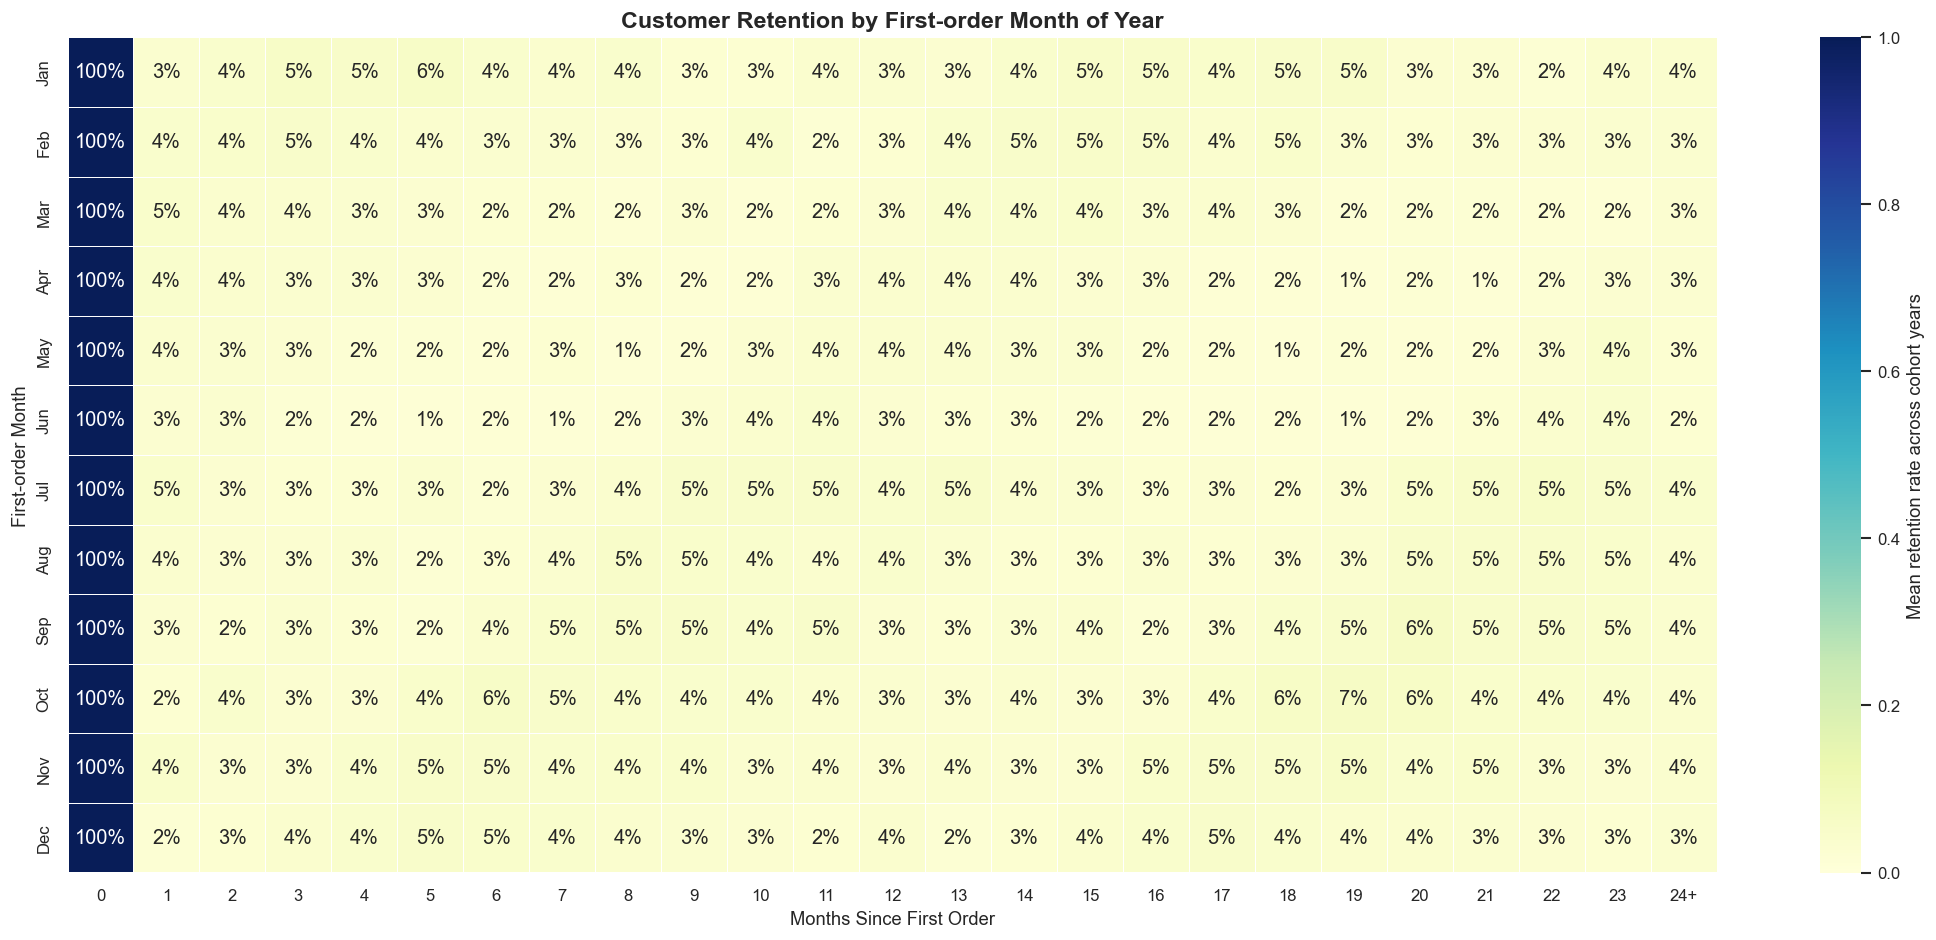

In [29]:
month_order = [
    "Jan", "Feb", "Mar", "Apr", "May", "Jun",
    "Jul", "Aug", "Sep", "Oct", "Nov", "Dec",
]
bucket_order = list(range(24)) + ["24+"]

retention_counts["cohort_index_bucket"] = retention_counts["cohort_index"].where(
    retention_counts["cohort_index"] < 24,
    "24+",
)

month_of_year_retention = (
    retention_counts.groupby(["cohort_start_month", "cohort_index_bucket"], as_index=False)
    .agg(
        mean_retention_rate=("retention_rate", "mean"),
        cohorts=("cohort_month", "nunique"),
    )
)
month_of_year_heatmap = (
    month_of_year_retention.pivot(
        index="cohort_start_month",
        columns="cohort_index_bucket",
        values="mean_retention_rate",
    )
    .reindex(index=month_order)
    .reindex(columns=bucket_order)
)
heatmap_labels = month_of_year_heatmap.map(lambda value: f"{value:.0%}" if pd.notna(value) else "")

fig, ax = plt.subplots(figsize=(18, 8))
sns.heatmap(
    month_of_year_heatmap,
    cmap="YlGnBu",
    vmin=0,
    vmax=1,
    linewidths=0.4,
    linecolor="white",
    annot=heatmap_labels,
    fmt="",
    cbar_kws={"label": "Mean retention rate across cohort years"},
    ax=ax,
)
ax.set_title("Customer Retention by First-order Month of Year")
ax.set_xlabel("Months Since First Order")
ax.set_ylabel("First-order Month")
plt.tight_layout()

## Year-grouped Cohort Retention Heatmap

This view groups first-order cohorts by calendar year instead of month-of-year, using the same `24+` horizon bucket to keep the chart readable.

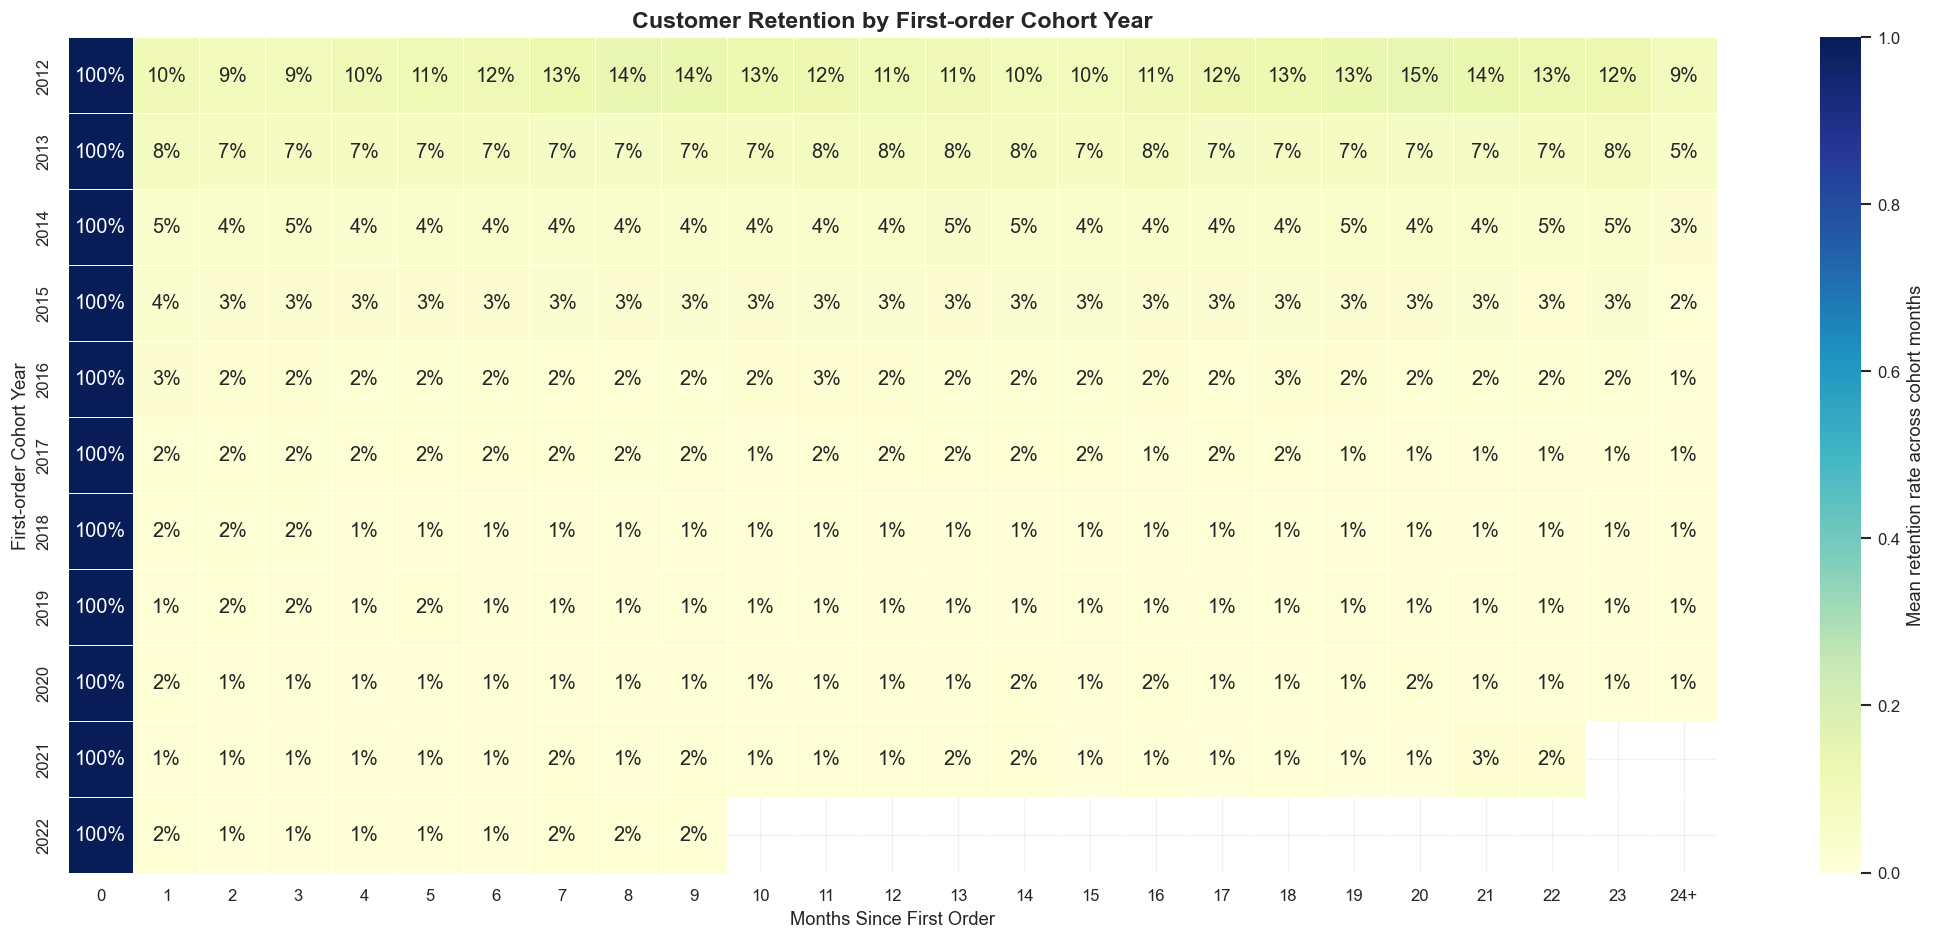

In [30]:
retention_counts["cohort_year"] = retention_counts["cohort_month"].dt.year

year_of_cohort_retention = (
    retention_counts.groupby(["cohort_year", "cohort_index_bucket"], as_index=False)
    .agg(
        mean_retention_rate=("retention_rate", "mean"),
        cohorts=("cohort_month", "nunique"),
    )
)
year_of_cohort_heatmap = (
    year_of_cohort_retention.pivot(
        index="cohort_year",
        columns="cohort_index_bucket",
        values="mean_retention_rate",
    )
    .sort_index()
    .reindex(columns=bucket_order)
)
heatmap_labels = year_of_cohort_heatmap.map(lambda value: f"{value:.0%}" if pd.notna(value) else "")

fig, ax = plt.subplots(figsize=(18, 8))
sns.heatmap(
    year_of_cohort_heatmap,
    cmap="YlGnBu",
    vmin=0,
    vmax=1,
    linewidths=0.4,
    linecolor="white",
    annot=heatmap_labels,
    fmt="",
    cbar_kws={"label": "Mean retention rate across cohort months"},
    ax=ax,
)
ax.set_title("Customer Retention by First-order Cohort Year")
ax.set_xlabel("Months Since First Order")
ax.set_ylabel("First-order Cohort Year")
plt.tight_layout()

### Business Insight

> Chart retention là phần nối tiếp trực tiếp của Chart 1: sau khi khách đã đi qua đơn đầu, câu hỏi tiếp theo là họ có quay lại đủ nhanh và đủ đều hay không.

### Hiện trạng dữ liệu
- Retention trung bình ở các mốc chính duy trì ở mức thấp: **~3.6% (M1)**, **~3.2% (M6)**, **~3.4% (M12)**, **~3.4% (24+)**.
- Theo tháng first-order, cohort **March/July** giữ chân sớm tốt hơn, trong khi **October/December** yếu hơn.
- Ở góc nhìn theo năm, cohort mới có xu hướng lặp lại kém ổn định hơn cohort cũ.

### Diễn giải vấn đề
- Nếu Chart 1 là câu hỏi “có bao nhiêu khách bước vào demand?”, thì Chart 2 trả lời “bao nhiêu người trong số đó thực sự biến thành repeat demand?”.
- Mô hình quay lại hiện tại mang tính phân tán, chưa tạo được chu kỳ mua lại đều ngay sau đơn đầu.
- Mùa phát sinh đơn đầu ảnh hưởng trực tiếp đến xác suất quay lại, nên retention không thể triển khai theo một công thức chung cho mọi cohort. Tuy nhiên, retention thấp ở các mốc đầu vẫn chưa đủ để kết luận khách rời bỏ; cần nhìn thêm khoảng thời gian từ đơn đầu đến đơn hai để phân biệt rõ quay lại muộn và rời bỏ thật sự.

### Tác động đến doanh nghiệp
- Khó dự báo doanh thu lặp lại theo tháng do nền retention sớm thấp và dao động theo mùa.
- Chi phí CRM dễ bị lãng phí nếu thông điệp và thời điểm chạm khách không khớp từng cohort.
- Tăng trưởng repeat không bền nếu cohort mới tiếp tục yếu hơn cohort cũ.

### Đề xuất ngắn gọn
- Vận hành retention theo cohort mùa vụ: ưu tiên tăng M1-M3 cho các cohort yếu (đặc biệt October/December) bằng kịch bản chăm sóc khác biệt theo tháng first-order.

## Retention Milestones

In [23]:
summary_months = [0, 1, 3, 6, 12]
retention_summary = (
    retention_counts[retention_counts["cohort_index"].isin(summary_months)]
    .pivot(index="cohort_month", columns="cohort_index", values="retention_rate")
    .rename(columns={month: f"m{month}" for month in summary_months if month in retention_counts["cohort_index"].values})
    .join(cohort_sizes.set_index("cohort_month"))
    .sort_index()
)
retention_summary.tail(12)

,m0,m1,m3,m6,m12,cohort_size
cohort_month,,,,,,
2022-01-01,1.0000,NaN,0.0189,NaN,NaN,53
2022-02-01,1.0000,0.0128,NaN,NaN,NaN,78
2022-03-01,1.0000,0.0234,0.0058,NaN,NaN,171
2022-04-01,1.0000,0.0123,0.0123,0.0062,NaN,162
2022-05-01,1.0000,0.0307,0.0123,NaN,NaN,163
2022-06-01,1.0000,0.0059,0.0059,0.0176,NaN,170
2022-07-01,1.0000,NaN,NaN,NaN,NaN,113
2022-08-01,1.0000,NaN,0.0076,NaN,NaN,132
2022-09-01,1.0000,NaN,0.0109,NaN,NaN,92


In [8]:
import matplotlib.ticker as mtick

customer_fact.shape, order_fact.shape, customer_cohort_activity.shape, signup_activation.shape

((121930, 46), (646945, 41), (586976, 13))

# Chart 3: Time-to-second-purchase Distribution

Compute the days from first to second order for repeat buyers, summarize median/IQR/p75/p90, and run window checks so recent cohorts are not overinterpreted.

In [31]:
repeat_base = customer_fact.loc[
    customer_fact["first_order_date"].notna(),
    ["customer_id", "first_order_date", "second_order_date", "orders_count"],
]
repeat_base["orders_count"] = repeat_base["orders_count"].fillna(0)

repeat_candidates = repeat_base[
    (repeat_base["orders_count"] >= 2) | repeat_base["second_order_date"].notna()
]
repeat_candidates["days_to_second_order_calc"] = (
    repeat_candidates["second_order_date"] - repeat_candidates["first_order_date"]
).dt.days

invalid_gap_mask = repeat_candidates["days_to_second_order_calc"].isna() | (
    repeat_candidates["days_to_second_order_calc"] <= 0
)
valid_repeat_gaps = repeat_candidates.loc[~invalid_gap_mask, "days_to_second_order_calc"]

timing_milestones = [7, 14, 30, 60, 90, 180, 365, 730, 1095, 1460]
repeat_timing_curve = pd.DataFrame(
    {
        "days_since_first_order": timing_milestones,
        "repeaters": [(valid_repeat_gaps <= days).sum() for days in timing_milestones],
    }
)
repeat_timing_curve["repeaters_share"] = (
    repeat_timing_curve["repeaters"] / valid_repeat_gaps.shape[0]
)

gap_quantiles = valid_repeat_gaps.quantile([0.25, 0.50, 0.75, 0.90])
median_gap = gap_quantiles.loc[0.50]
iqr_gap = gap_quantiles.loc[0.75] - gap_quantiles.loc[0.25]
p75_gap = gap_quantiles.loc[0.75]
p90_gap = gap_quantiles.loc[0.90]

analysis_end_date = order_fact["order_date"].max()
repeat_base["observable_window_days"] = (
    analysis_end_date - repeat_base["first_order_date"]
).dt.days
repeat_base["eligible_for_p90_window"] = repeat_base["observable_window_days"] >= p90_gap
repeat_base["is_valid_repeater"] = repeat_base["customer_id"].isin(
    repeat_candidates.loc[~invalid_gap_mask, "customer_id"]
)

gap_summary = pd.DataFrame(
    [
        {
            "repeat_buyers_candidates": int(len(repeat_candidates)),
            "valid_repeat_gaps_used": int(valid_repeat_gaps.shape[0]),
            "removed_invalid_zero_or_negative_gap": int(invalid_gap_mask.sum()),
            "median_days": float(median_gap),
            "iqr_days": float(iqr_gap),
            "p75_days": float(p75_gap),
            "p90_days": float(p90_gap),
        }
    ]
)

window_check = pd.DataFrame(
    [
        {
            "analysis_end_date": analysis_end_date,
            "p90_gap_days": float(p90_gap),
            "purchasers_total": int(len(repeat_base)),
            "purchasers_eligible_for_p90_window": int(repeat_base["eligible_for_p90_window"].sum()),
            "eligible_share": float(repeat_base["eligible_for_p90_window"].mean()),
            "repeat_rate_all_purchasers": float(repeat_base["is_valid_repeater"].mean()),
            "repeat_rate_p90_eligible_only": float(
                repeat_base.loc[
                    repeat_base["eligible_for_p90_window"],
                    "is_valid_repeater",
                ].mean()
            ),
        }
    ]
)

cohort_window_check = (
    repeat_base.assign(
        first_order_cohort_month=repeat_base["first_order_date"].dt.to_period("M").dt.to_timestamp()
    )
    .groupby("first_order_cohort_month", as_index=False)
    .agg(
        purchasers=("customer_id", "nunique"),
        eligible_for_p90_window=("eligible_for_p90_window", "sum"),
        valid_repeaters=("is_valid_repeater", "sum"),
    )
    .sort_values("first_order_cohort_month")
)
cohort_window_check["eligibility_rate"] = (
    cohort_window_check["eligible_for_p90_window"] / cohort_window_check["purchasers"]
)
cohort_window_check["repeat_rate_observed"] = (
    cohort_window_check["valid_repeaters"] / cohort_window_check["purchasers"]
)
cohort_window_check["repeat_rate_eligible_only"] = (
    cohort_window_check["valid_repeaters"]
    / cohort_window_check["eligible_for_p90_window"].replace(0, pd.NA)
)

cohort_horizon = (
    customer_cohort_activity.groupby("first_order_cohort_month", as_index=False)["cohort_index"]
    .max()
    .rename(columns={"cohort_index": "max_observed_cohort_index"})
)
cohort_window_check = cohort_window_check.merge(
    cohort_horizon,
    on="first_order_cohort_month",
    how="left",
)

display(gap_summary)
display(window_check)
cohort_window_check.tail(12)

,repeat_buyers_candidates,valid_repeat_gaps_used,removed_invalid_zero_or_negative_gap,median_days,iqr_days,p75_days,p90_days
0,67888,67320,568,299.0000,618.2500,717.2500,1365.0000


,analysis_end_date,p90_gap_days,purchasers_total,purchasers_eligible_for_p90_window,eligible_share,repeat_rate_all_purchasers,repeat_rate_p90_eligible_only
0,2022-12-31,1365.0000,90246,84664,0.9381,0.7460,0.7856


,first_order_cohort_month,purchasers,eligible_for_p90_window,valid_repeaters,eligibility_rate,repeat_rate_observed,repeat_rate_eligible_only,max_observed_cohort_index
114,2022-01-01,53,0,6,0.0000,0.1132,<NA>,9
115,2022-02-01,78,0,2,0.0000,0.0256,<NA>,7
116,2022-03-01,171,0,8,0.0000,0.0468,<NA>,5
117,2022-04-01,162,0,8,0.0000,0.0494,<NA>,7
118,2022-05-01,163,0,15,0.0000,0.0920,<NA>,7
119,2022-06-01,170,0,11,0.0000,0.0647,<NA>,6
120,2022-07-01,113,0,3,0.0000,0.0265,<NA>,5
121,2022-08-01,132,0,3,0.0000,0.0227,<NA>,4
122,2022-09-01,92,0,3,0.0000,0.0326,<NA>,3
123,2022-10-01,51,0,0,0.0000,0.0000,<NA>,0


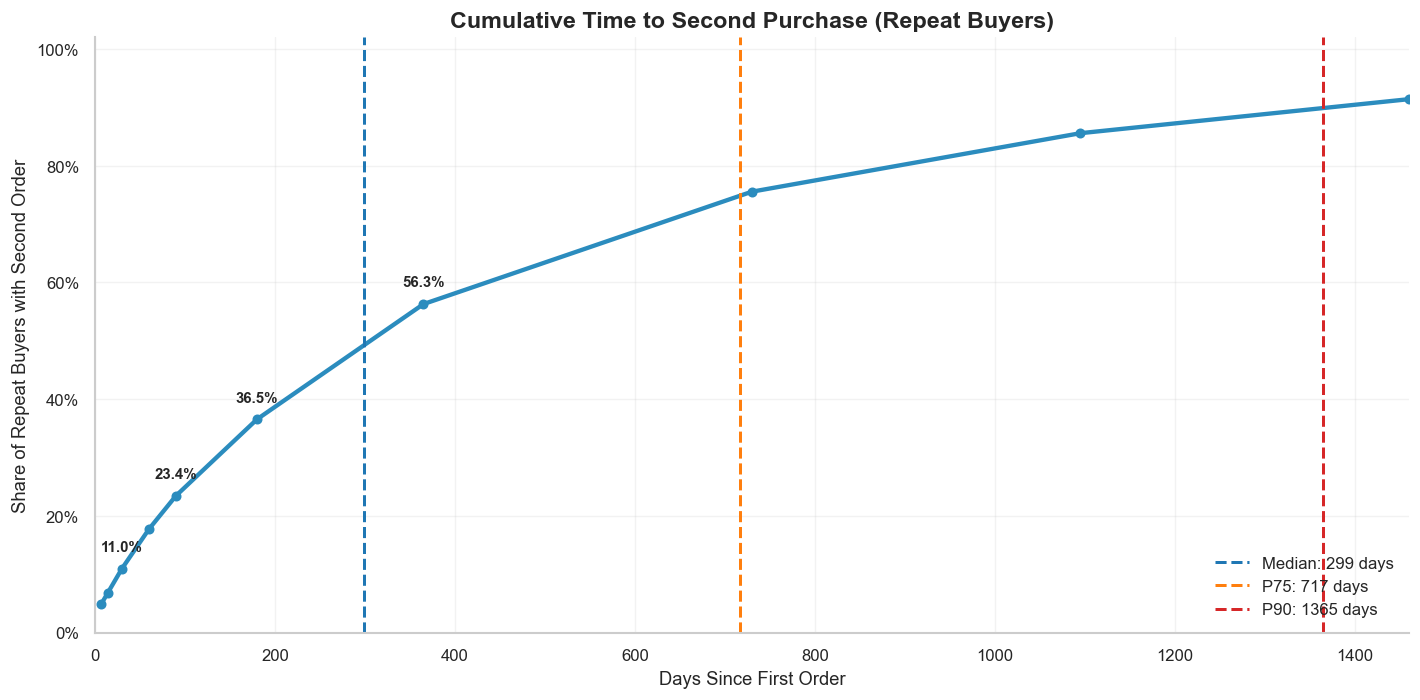

In [32]:
fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(
    repeat_timing_curve["days_since_first_order"],
    repeat_timing_curve["repeaters_share"],
    marker="o",
    linewidth=2.6,
    color="#2b8cbe",
)

for _, row in repeat_timing_curve.iterrows():
    if row["days_since_first_order"] in [30, 90, 180, 365]:
        ax.text(
            row["days_since_first_order"],
            row["repeaters_share"] + 0.025,
            f"{row['repeaters_share']:.1%}",
            ha="center",
            va="bottom",
            fontsize=9,
            fontweight="bold",
        )

for label, value, color in [
    ("Median", median_gap, "#1f77b4"),
    ("P75", p75_gap, "#ff7f0e"),
    ("P90", p90_gap, "#d62728"),
]:
    ax.axvline(value, color=color, linestyle="--", linewidth=1.8, label=f"{label}: {value:.0f} days")

ax.set_title("Cumulative Time to Second Purchase (Repeat Buyers)")
ax.set_xlabel("Days Since First Order")
ax.set_ylabel("Share of Repeat Buyers with Second Order")
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax.set_xlim(0, repeat_timing_curve["days_since_first_order"].max())
ax.set_ylim(0, 1.02)
ax.grid(alpha=0.25)
ax.legend(loc="lower right")
plt.tight_layout()

### Business Insight

> Chart time-to-second-purchase giải thích vì sao retention ở Chart 2 nhìn thấp: repeat không biến mất, mà chủ yếu xảy ra rất muộn.

### Hiện trạng dữ liệu
- Tỷ lệ quay lại sớm còn thấp: **11.7%** trong **30 ngày**, **24.1%** trong **90 ngày**, **37.1%** trong **180 ngày**.
- **Median time-to-second-purchase ~294 ngày**; khoảng **56.7%** quay lại trong **365 ngày**.
- Điều này cho thấy phần lớn repeat buyers quay lại muộn, không tập trung trong một cửa sổ ngắn.

### Diễn giải vấn đề
- Chart 2 cho thấy retention thấp ở các mốc đầu, nhưng Chart 3 nói rõ nguyên nhân là nhịp quay lại bị kéo dài, không phải demand repeat đã biến mất hoàn toàn.
- KPI 30/60/90 ngày nếu dùng làm chuẩn chính sẽ tạo thiên lệch đánh giá, dễ kết luận sai rằng khách "không quay lại".
- Bản chất sản phẩm/hành vi mua có thể thuộc nhóm nhu cầu giãn cách dài, nên doanh nghiệp cần chăm sóc theo vòng đời dài hơn thay vì chỉ đẩy promo ngắn hạn. Đặt cạnh Chart 1 và Chart 2, bức tranh trở nên rõ hơn: doanh nghiệp vừa phải kéo thêm khách qua đơn đầu, vừa phải quản trị đúng nhịp quay lại dài chu kỳ để chuyển one-time thành repeat bền vững.

### Tác động đến doanh nghiệp
- Dự báo LTV ngắn hạn bị thấp hơn thực tế, kéo theo rủi ro cắt giảm sai ngân sách giữ chân.
- Hiệu quả chiến dịch có thể bị đánh giá âm giả do cửa sổ đo lường không đủ dài.
- Doanh thu quay lại bị bỏ lỡ khi thiếu chương trình tái kích hoạt trung và dài hạn.

### Đề xuất ngắn gọn
- Tách CRM thành 2 nhịp: nhịp tăng tốc tái mua (0-90 ngày) và nhịp nuôi dưỡng/tái kích hoạt (90-365 ngày), đồng thời đo hiệu quả theo cửa sổ dài hơn.

# Chart 4: Repeat Rate by Acquisition Channel

Compare acquisition channels across the same funnel stages: customer volume, first-order activation, and ordered-to-repeat conversion.

In [33]:
channel_base = customer_fact[["customer_id", "acquisition_channel", "orders_count"]].copy()
channel_base["orders_count"] = channel_base["orders_count"].fillna(0)

channel_base["acquisition_channel_clean"] = (
    channel_base["acquisition_channel"].astype("string").str.strip()
)
missing_channel_mask = channel_base["acquisition_channel_clean"].isna() | (
    channel_base["acquisition_channel_clean"] == ""
 )
channel_base.loc[missing_channel_mask, "acquisition_channel_clean"] = "Unknown"

channel_stats = (
    channel_base.groupby("acquisition_channel_clean", as_index=False)
    .agg(
        customer_count=("customer_id", "nunique"),
        purchaser_count=("orders_count", lambda values: int((values > 0).sum())),
        repeat_customer_count=("orders_count", lambda values: int((values >= 2).sum())),
    )
)
channel_stats["repeat_rate"] = (
    channel_stats["repeat_customer_count"]
    / channel_stats["purchaser_count"].replace(0, pd.NA)
)
channel_stats["order_rate"] = (
    channel_stats["purchaser_count"]
    / channel_stats["customer_count"].replace(0, pd.NA)
)
channel_stats["repeat_rate_all_customers"] = (
    channel_stats["repeat_customer_count"]
    / channel_stats["customer_count"].replace(0, pd.NA)
)
channel_stats["one_time_customer_count"] = (
    channel_stats["purchaser_count"] - channel_stats["repeat_customer_count"]
)

channel_missingness = pd.DataFrame(
    [
        {
            "customers_total": int(channel_base["customer_id"].nunique()),
            "missing_or_blank_channel_customers": int(missing_channel_mask.sum()),
            "missing_or_blank_channel_pct": float(missing_channel_mask.mean()),
        }
    ]
)

min_customer_threshold = max(50, int(0.01 * channel_base["customer_id"].nunique()))
small_channels = channel_stats.loc[
    channel_stats["customer_count"] < min_customer_threshold,
    [
        "acquisition_channel_clean",
        "customer_count",
        "purchaser_count",
        "repeat_customer_count",
        "repeat_rate",
    ],
]
small_channels = small_channels.sort_values("customer_count")

channel_stats["channel_grouped"] = channel_stats["acquisition_channel_clean"].where(
    channel_stats["customer_count"] >= min_customer_threshold,
    "Other",
)

channel_grouped = (
    channel_stats.groupby("channel_grouped", as_index=False)
    .agg(
        customer_count=("customer_count", "sum"),
        purchaser_count=("purchaser_count", "sum"),
        repeat_customer_count=("repeat_customer_count", "sum"),
        one_time_customer_count=("one_time_customer_count", "sum"),
    )
)
channel_grouped["repeat_rate"] = (
    channel_grouped["repeat_customer_count"]
    / channel_grouped["purchaser_count"].replace(0, pd.NA)
)
channel_grouped["order_rate"] = (
    channel_grouped["purchaser_count"]
    / channel_grouped["customer_count"].replace(0, pd.NA)
)
channel_grouped["repeat_rate_all_customers"] = (
    channel_grouped["repeat_customer_count"]
    / channel_grouped["customer_count"].replace(0, pd.NA)
)
channel_grouped = channel_grouped.sort_values("repeat_rate", ascending=False).reset_index(drop=True)

display(channel_missingness)
display(
    pd.DataFrame(
        [
            {
                "tiny_channel_threshold_customers": min_customer_threshold,
                "num_tiny_channels_grouped_into_other": int(small_channels.shape[0]),
            }
        ]
    )
)
display(small_channels)
channel_grouped

,customers_total,missing_or_blank_channel_customers,missing_or_blank_channel_pct
0,121930,0,0.0000


,tiny_channel_threshold_customers,num_tiny_channels_grouped_into_other
0,1219,0


,acquisition_channel_clean,customer_count,purchaser_count,repeat_customer_count,repeat_rate


,channel_grouped,customer_count,purchaser_count,repeat_customer_count,one_time_customer_count,repeat_rate,order_rate,repeat_rate_all_customers
0,social_media,24448,18002,13623,4379,0.7567,0.7363,0.5572
1,organic_search,36450,26950,20316,6634,0.7538,0.7394,0.5574
2,referral,12270,9072,6816,2256,0.7513,0.7394,0.5555
3,paid_search,24285,17999,13503,4496,0.7502,0.7412,0.5560
4,direct,9803,7337,5491,1846,0.7484,0.7484,0.5601
5,email_campaign,14674,10886,8139,2747,0.7477,0.7419,0.5547


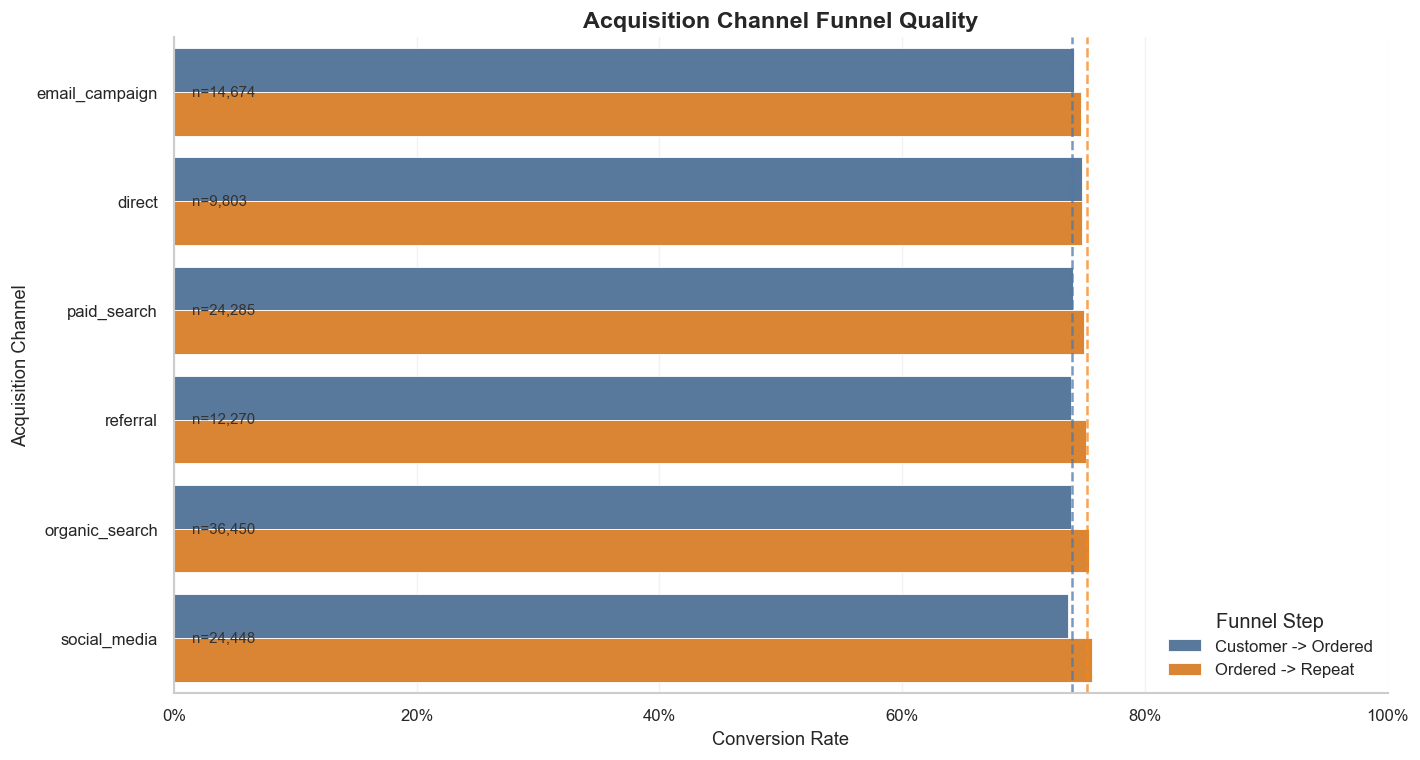

In [34]:
plot_channel = channel_grouped.sort_values("repeat_rate", ascending=True).reset_index(drop=True)
channel_rate_plot = plot_channel.melt(
    id_vars=[
        "channel_grouped",
        "customer_count",
        "purchaser_count",
        "repeat_customer_count",
    ],
    value_vars=["order_rate", "repeat_rate"],
    var_name="metric",
    value_name="rate",
)
channel_rate_plot["metric"] = channel_rate_plot["metric"].map(
    {
        "order_rate": "Customer -> Ordered",
        "repeat_rate": "Ordered -> Repeat",
    }
)

fig, ax = plt.subplots(figsize=(12, 6.5))
sns.barplot(
    data=channel_rate_plot,
    x="rate",
    y="channel_grouped",
    hue="metric",
    palette={"Customer -> Ordered": "#4c78a8", "Ordered -> Repeat": "#f58518"},
    ax=ax,
)

for idx, row in plot_channel.iterrows():
    ax.text(
        0.015,
        idx,
        f"n={int(row['customer_count']):,}",
        va="center",
        ha="left",
        fontsize=9,
        color="#333333",
    )

overall_order_rate = channel_grouped["purchaser_count"].sum() / channel_grouped["customer_count"].sum()
overall_repeat_rate = channel_grouped["repeat_customer_count"].sum() / channel_grouped["purchaser_count"].sum()
ax.axvline(overall_order_rate, color="#4c78a8", linestyle="--", linewidth=1.5, alpha=0.75)
ax.axvline(overall_repeat_rate, color="#f58518", linestyle="--", linewidth=1.5, alpha=0.75)

ax.set_xlim(0, 1.0)
ax.xaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax.set_title("Acquisition Channel Funnel Quality")
ax.set_xlabel("Conversion Rate")
ax.set_ylabel("Acquisition Channel")
ax.legend(title="Funnel Step", loc="lower right")
ax.grid(axis="x", alpha=0.25)
ax.set_axisbelow(True)
plt.tight_layout()

### Business Insight

> Chart 4 cho tôi thấy chất lượng demand giữa các kênh khá sát nhau, nên bài toán không phải chọn một kênh thắng tuyệt đối mà là hiểu kênh nào tạo ra base khách đủ lớn và ổn định hơn.

### Hiện trạng dữ liệu
- Hai tỷ lệ chính (**Customer -> Ordered** và **Ordered -> Repeat**) dao động trong biên độ hẹp giữa các kênh.
- **Direct** nhỉnh hơn ở activation, **Social Media** nhỉnh nhẹ ở repeat nhưng chưa có kênh nào vượt trội tuyệt đối.
- Khi chênh lệch tỷ lệ nhỏ, quy mô khách của từng kênh mới là yếu tố quyết định tác động doanh thu thực tế.

### Diễn giải vấn đề
- Với góc nhìn demand, kênh nào cũng đang tạo ra khách hàng ở mức tương đối gần nhau, nghĩa là ưu tiên không nằm ở việc thay đổi toàn bộ chiến lược acquisition.
- Điều cần nhìn là kênh nào tạo được khách đủ đều để nuôi qua các bước tiếp theo trong funnel.
- Nói cách khác, Chart 4 giúp doanh nghiệp hiểu rằng vấn đề không phải thiếu traffic, mà là chưa chuyển traffic thành khách có giá trị trọn vòng đời đủ tốt.

### Tác động đến doanh nghiệp
- Nếu chỉ tối ưu theo rate mà bỏ qua volume, doanh nghiệp dễ đánh giá sai hiệu quả thật của từng kênh.
- Ngược lại, nếu chỉ nhìn volume mà không nhìn quality, doanh nghiệp có thể đẩy ngân sách vào kênh lớn nhưng ít tạo repeat value.
- Kênh tốt là kênh vừa mang khách vào được, vừa không làm rơi chất lượng quá mạnh ở các bước sau.

### Đề xuất ngắn gọn
- Ưu tiên kênh có volume lớn và hiệu quả ổn định, đồng thời tối ưu trải nghiệm sau mua thay vì kỳ vọng thay đổi lớn chỉ từ việc đổi kênh acquisition.

# Chart 5: Customer Revenue Concentration Curve

Compare how concentrated net revenue is across ordered customers, benchmark it against order-count concentration, and quantify how much revenue is carried by the top customer groups.

In [35]:
revenue_metric = "net_revenue_proxy" if "net_revenue_proxy" in customer_fact.columns else "net_revenue"

revenue_base = customer_fact.loc[
    customer_fact["first_order_date"].notna(),
    ["customer_id", "orders_count", revenue_metric],
]
revenue_base["orders_count"] = revenue_base["orders_count"].fillna(0)
revenue_base[revenue_metric] = revenue_base[revenue_metric].fillna(0.0)

order_revenue_by_customer = (
    order_fact.groupby("customer_id", as_index=False)[revenue_metric]
    .sum()
    .rename(columns={revenue_metric: "order_fact_revenue"})
)

revenue_consistency = revenue_base.merge(order_revenue_by_customer, on="customer_id", how="left")
revenue_consistency["order_fact_revenue"] = revenue_consistency["order_fact_revenue"].fillna(0.0)
revenue_consistency["abs_gap"] = (
    revenue_consistency[revenue_metric] - revenue_consistency["order_fact_revenue"]
).abs()

consistency_summary = pd.DataFrame(
    [
        {
            "revenue_metric_used": revenue_metric,
            "total_revenue_customer_fact": float(revenue_consistency[revenue_metric].sum()),
            "total_revenue_order_fact": float(revenue_consistency["order_fact_revenue"].sum()),
            "absolute_total_gap": float(
                abs(
                    revenue_consistency[revenue_metric].sum()
                    - revenue_consistency["order_fact_revenue"].sum()
                )
            ),
            "median_abs_customer_gap": float(revenue_consistency["abs_gap"].median()),
            "p95_abs_customer_gap": float(revenue_consistency["abs_gap"].quantile(0.95)),
            "customers_with_abs_gap_gt_1": int((revenue_consistency["abs_gap"] > 1).sum()),
        }
    ]
)

non_positive_revenue_customers = int((revenue_base[revenue_metric] <= 0).sum())
concentration_base = revenue_base.loc[revenue_base[revenue_metric] > 0].copy()

revenue_curve = concentration_base.sort_values(revenue_metric, ascending=False).reset_index(drop=True)
revenue_curve["cum_customer_share"] = (revenue_curve.index + 1) / len(revenue_curve)
revenue_curve["cum_revenue_share"] = (
    revenue_curve[revenue_metric].cumsum() / revenue_curve[revenue_metric].sum()
)

order_curve = concentration_base.sort_values("orders_count", ascending=False).reset_index(drop=True)
order_curve["cum_customer_share"] = (order_curve.index + 1) / len(order_curve)
order_total = order_curve["orders_count"].sum()
order_curve["cum_order_share"] = (
    order_curve["orders_count"].cumsum() / order_total if order_total > 0 else 0.0
)

def top_share(curve_source: pd.DataFrame, value_col: str, top_pct: float) -> float:
    top_n = max(1, int(round(len(curve_source) * top_pct)))
    return float(
        curve_source.nlargest(top_n, value_col)[value_col].sum()
        / curve_source[value_col].sum()
    )

def customer_share_to_revenue_share(curve_source: pd.DataFrame, value_col: str, revenue_share: float) -> float:
    ordered = curve_source.sort_values(value_col, ascending=False).reset_index(drop=True)
    cumulative_share = ordered[value_col].cumsum() / ordered[value_col].sum()
    customer_count = int((cumulative_share >= revenue_share).idxmax() + 1)
    return float(customer_count / len(ordered))

concentration_snapshot = pd.DataFrame(
    [
        {
            "customers_in_curve": int(len(concentration_base)),
            "excluded_non_positive_revenue_customers": non_positive_revenue_customers,
            "top_1pct_revenue_share": top_share(concentration_base, revenue_metric, 0.01),
            "top_5pct_revenue_share": top_share(concentration_base, revenue_metric, 0.05),
            "top_10pct_revenue_share": top_share(concentration_base, revenue_metric, 0.10),
            "top_20pct_revenue_share": top_share(concentration_base, revenue_metric, 0.20),
            "customer_share_for_50pct_revenue": customer_share_to_revenue_share(concentration_base, revenue_metric, 0.50),
            "customer_share_for_75pct_revenue": customer_share_to_revenue_share(concentration_base, revenue_metric, 0.75),
            "customer_share_for_90pct_revenue": customer_share_to_revenue_share(concentration_base, revenue_metric, 0.90),
        }
    ]
)

display(consistency_summary)
concentration_snapshot

,revenue_metric_used,total_revenue_customer_fact,total_revenue_order_fact,absolute_total_gap,median_abs_customer_gap,p95_abs_customer_gap,customers_with_abs_gap_gt_1
0,net_revenue_proxy,15680869265.4300,15680869265.4300,0.0000,0.0000,0.0000,0


,customers_in_curve,excluded_non_positive_revenue_customers,top_1pct_revenue_share,top_5pct_revenue_share,top_10pct_revenue_share,top_20pct_revenue_share,customer_share_for_50pct_revenue,customer_share_for_75pct_revenue,customer_share_for_90pct_revenue
0,90246,0,0.0727,0.2483,0.3998,0.6066,0.1428,0.3072,0.5059


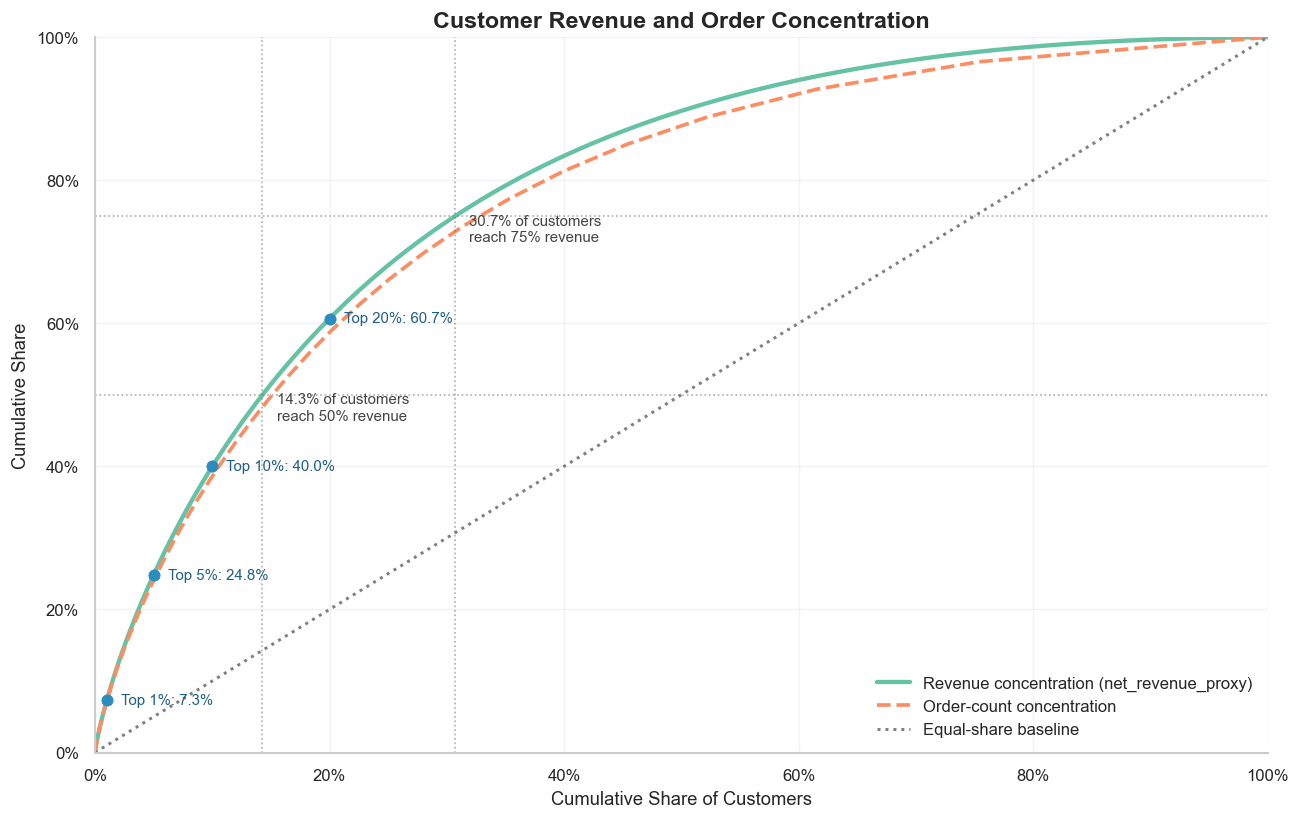

In [36]:
fig, ax = plt.subplots(figsize=(11, 7))
ax.plot(
    revenue_curve["cum_customer_share"],
    revenue_curve["cum_revenue_share"],
    label=f"Revenue concentration ({revenue_metric})",
    linewidth=2.6,
)
ax.plot(
    order_curve["cum_customer_share"],
    order_curve["cum_order_share"],
    label="Order-count concentration",
    linewidth=2.2,
    linestyle="--",
)
ax.plot(
    [0, 1],
    [0, 1],
    color="gray",
    linestyle=":",
    linewidth=1.8,
    label="Equal-share baseline",
)

for customer_share in [0.01, 0.05, 0.10, 0.20]:
    top_n = max(1, int(round(len(revenue_curve) * customer_share)))
    point = revenue_curve.iloc[top_n - 1]
    ax.scatter(
        point["cum_customer_share"],
        point["cum_revenue_share"],
        s=45,
        color="#2b8cbe",
        zorder=3,
    )
    ax.text(
        point["cum_customer_share"] + 0.012,
        point["cum_revenue_share"],
        f"Top {customer_share:.0%}: {point['cum_revenue_share']:.1%}",
        va="center",
        fontsize=9,
        color="#1f5f85",
    )

for revenue_share in [0.50, 0.75]:
    threshold_idx = int((revenue_curve["cum_revenue_share"] >= revenue_share).idxmax())
    point = revenue_curve.iloc[threshold_idx]
    ax.axhline(revenue_share, color="#777777", linestyle=":", linewidth=1, alpha=0.6)
    ax.axvline(point["cum_customer_share"], color="#777777", linestyle=":", linewidth=1, alpha=0.6)
    ax.text(
        point["cum_customer_share"] + 0.012,
        revenue_share - 0.035,
        f"{point['cum_customer_share']:.1%} of customers\nreach {revenue_share:.0%} revenue",
        fontsize=9,
        color="#444444",
    )

ax.set_title("Customer Revenue and Order Concentration")
ax.set_xlabel("Cumulative Share of Customers")
ax.set_ylabel("Cumulative Share")
ax.xaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.grid(alpha=0.25)
ax.legend(loc="lower right")
plt.tight_layout()

### Business Insight

> Chart 5 cho thấy doanh thu không trải đều trên toàn bộ tệp khách; một nhóm khách vừa phải đang tạo ra phần lớn giá trị, và đây là nhóm doanh nghiệp cần nhìn thật kỹ trong demand story.

### Hiện trạng dữ liệu
- Top **1%** khách đóng góp khoảng **7.3%** doanh thu; top **5%** đóng góp **24.8%**; top **10%** đóng góp **40.0%**.
- Khoảng **14.3%** khách tạo ra **50%** doanh thu; khoảng **30.7%** khách tạo ra **75%** doanh thu.
- Đường concentration doanh thu khá gần đường concentration theo số đơn, cho thấy doanh thu đang đi cùng tần suất mua chứ không bị kéo bởi một vài đơn hàng quá lớn.

### Diễn giải vấn đề
- Đây là tín hiệu rất quan trọng cho phần demand: doanh nghiệp không chỉ cần nhiều khách hơn, mà cần giữ được đúng nhóm khách có khả năng tạo giá trị lặp lại.
- Nếu chăm sóc đại trà, ngân sách giữ chân sẽ bị dàn mỏng cho cả nhóm ít giá trị.
- Nếu chỉ tập trung vào nhóm quá nhỏ, doanh nghiệp sẽ bỏ lỡ lớp khách trung-cao, vốn là nơi doanh thu tích lũy bền nhất.

### Tác động đến doanh nghiệp
- CLV trung bình khó tăng nếu không có chiến lược riêng cho nhóm top 10% và nhóm 10-30%.
- Biên lợi nhuận có thể bị mòn đi nếu ưu đãi áp dụng đồng loạt, không phân biệt giá trị khách.
- Tệp khách tạo doanh thu chủ lực sẽ dễ bị phụ thuộc quá mức nếu doanh nghiệp không mở rộng được lớp khách trung-cao.

### Đề xuất ngắn gọn
- Phân tầng CRM theo giá trị khách và ưu tiên nhóm tạo doanh thu tích lũy tốt nhất, thay vì xử lý toàn bộ tệp theo một chính sách chung.

### Đúc Kết

 > Nếu nhìn toàn bộ Demand-side như một câu chuyện kinh doanh, thì chúng ta không đang đối mặt với bài toán **"thiếu khách"**, mà đang đối mặt với bài toán **"mất khách theo từng chặng"**.

Từ **Chart 1**, bức tranh mở ra khá rõ: khách rơi ngay ở cửa vào (signup nhưng chưa mua) và tiếp tục rơi thêm một lớp ngay sau đơn đầu (one-time). Điều này có nghĩa là tăng trưởng hiện tại bị nghẽn ở cả hai đầu của cùng một hành trình: vừa chưa kéo đủ khách đi qua mốc first order, vừa chưa giữ được động lực để họ quay lại lần hai.

Sang **Chart 2**, câu chuyện đi sâu hơn vào chất lượng phần khách đã mua. Chúng ta thấy retention mỏng ở các mốc đầu và biến động theo cohort theo mùa. Nói cách khác, khách không biến mất hoàn toàn, nhưng nhịp quay lại **không đều** và **không đủ chắc** để tạo một nền doanh thu lặp lại ổn định theo tháng.

Đến **Chart 3**, nguyên nhân được giải thích rõ hơn: chu kỳ quay lại của khách là chu kỳ dài. Khi thời gian mua lần hai có median quanh **294 ngày**, việc đánh giá hiệu quả chỉ bằng các mốc 30-90 ngày sẽ khiến doanh nghiệp nhìn thiếu giá trị thật của repeat demand và có nguy cơ ra quyết định ngắn hạn quá sớm.

Tiếp theo, **Chart 4** cho thấy khác biệt giữa các kênh acquisition không quá cực đoan như kỳ vọng. Vì vậy, vấn đề không nằm ở việc "đổi kênh thần kỳ", mà nằm ở việc biến lượng traffic hiện có thành tệp khách đi xa hơn trong funnel. **Chart 5** khép lại bằng một sự thật quan trọng: doanh thu **không trải đều**; một nhóm khách vừa phải đang tạo ra **phần lớn giá trị**. Điều đó buộc doanh nghiệp phải chuyển từ tư duy chăm sóc đại trà sang tư duy ưu tiên theo giá trị khách hàng.

### Tổng Hợp Vấn Đề
Điểm nghẽn cốt lõi của doanh nghiệp là **chưa có một cơ chế xuyên suốt** để đưa khách từ đăng ký sang mua đầu, từ mua đầu sang mua lặp lại, rồi từ mua lặp lại sang nhóm khách giá trị cao bền vững. Vì vậy, dù vẫn có traffic và đơn hàng mới, tăng trưởng vẫn bị giới hạn bởi tình trạng **rò rỉ liên tục dọc theo toàn bộ hành trình khách hàng**.

### Giải Pháp Khắc Phục
Để cải thiện bền vững, doanh nghiệp cần triển khai đồng thời ba hướng hành động: **(1) nâng tỷ lệ mua lần đầu** bằng cách đơn giản hóa quyết định mua ngay sau đăng ký; **(2) tăng tần suất quay lại** thông qua chăm sóc khách hàng đúng thời điểm trong suốt vòng đời mua sắm; và **(3) ưu tiên nhóm khách hàng tạo giá trị cao** bằng chính sách chăm sóc và ưu đãi theo mức độ đóng góp. Khi thực hiện nhất quán ba hướng này, doanh nghiệp sẽ củng cố nền tăng trưởng doanh thu lặp lại và tạo tiền đề vững chắc để bước sang phần phân tích Supply, nơi cần xác nhận hệ thống tồn kho có đang đáp ứng đúng nhu cầu thực tế hay không.